In [1]:
import subprocess, sys

for pkg in ["mysql-connector-python","requests","beautifulsoup4",
            "pandas","numpy","matplotlib","seaborn","tqdm"]:
    subprocess.check_call([sys.executable,"-m","pip","install",pkg,"-q"])

print("Done.")

Done.


In [2]:
# ── EDIT ONLY THIS CELL ──────────────────────────────────────
MYSQL_HOST     = "localhost"
MYSQL_PORT     = 3306
MYSQL_USER     = "root"
MYSQL_PASSWORD = "learning123@"   # ← your MySQL Workbench password
MYSQL_DATABASE = "job_market"

SEARCH_QUERIES = [
    {"keyword":"data analyst",     "location":"bangalore"},
    {"keyword":"data analyst",     "location":"mumbai"},
    {"keyword":"data analyst",     "location":"delhi"},
    {"keyword":"data analyst",     "location":"hyderabad"},
    {"keyword":"business analyst", "location":"bangalore"},
    {"keyword":"business analyst", "location":"mumbai"},
    {"keyword":"data engineer",    "location":"bangalore"},
    {"keyword":"machine learning", "location":"bangalore"},
    {"keyword":"product analyst",  "location":"bangalore"},
    {"keyword":"data analyst",     "location":"pune"},
]

MAX_PAGES = 5
DELAY_MIN = 3
DELAY_MAX = 6
TIMEOUT   = 15

import os
os.makedirs("data/raw",   exist_ok=True)
os.makedirs("data/clean", exist_ok=True)
RAW_PATH    = os.path.join("data","raw",  "raw_jobs.csv")
CLEAN_PATH  = os.path.join("data","clean","clean_jobs.csv")
SKILLS_PATH = os.path.join("data","clean","clean_skills_exploded.csv")

print("Config ready.")

Config ready.


In [3]:
import mysql.connector
from mysql.connector import Error

# Test connection first
try:
    conn = mysql.connector.connect(
        host=MYSQL_HOST, port=MYSQL_PORT,
        user=MYSQL_USER, password=MYSQL_PASSWORD
    )
    print("Connected:", conn.get_server_info())
    conn.close()
except Error as e:
    print("FAILED:", e)
    print("Fix: Is MySQL running? Is password correct?")

Connected: 8.0.45


C:\Users\hp\AppData\Local\Temp\ipykernel_10832\925405058.py:10: DeprecationWarning: Call to deprecated function get_server_info. Reason: 
    The property counterpart 'server_info' should be used instead.

  print("Connected:", conn.get_server_info())


In [4]:
conn   = mysql.connector.connect(
    host=MYSQL_HOST, port=MYSQL_PORT,
    user=MYSQL_USER, password=MYSQL_PASSWORD
)
cursor = conn.cursor()
cursor.execute(f"CREATE DATABASE IF NOT EXISTS {MYSQL_DATABASE}")
cursor.execute(f"USE {MYSQL_DATABASE}")

TABLES = [
    """CREATE TABLE IF NOT EXISTS dim_date (
        date_id      INT PRIMARY KEY AUTO_INCREMENT,
        full_date    DATE NOT NULL UNIQUE,
        week_number  TINYINT NOT NULL,
        month        TINYINT NOT NULL,
        quarter      TINYINT NOT NULL,
        year         SMALLINT NOT NULL,
        is_month_end BOOLEAN NOT NULL DEFAULT FALSE
    )""",
    """CREATE TABLE IF NOT EXISTS dim_location (
        location_id INT PRIMARY KEY AUTO_INCREMENT,
        city        VARCHAR(100) NOT NULL,
        state       VARCHAR(100),
        region      VARCHAR(50),
        tier        TINYINT
    )""",
    """CREATE TABLE IF NOT EXISTS dim_company (
        company_id    INT PRIMARY KEY AUTO_INCREMENT,
        company_name  VARCHAR(200) NOT NULL,
        industry      VARCHAR(100),
        company_size  VARCHAR(50),
        funding_stage VARCHAR(50)
    )""",
    """CREATE TABLE IF NOT EXISTS dim_role (
        role_id       INT PRIMARY KEY AUTO_INCREMENT,
        job_title     VARCHAR(200) NOT NULL,
        role_category VARCHAR(50) NOT NULL,
        exp_level     VARCHAR(20) NOT NULL
    )""",
    """CREATE TABLE IF NOT EXISTS dim_skill (
        skill_id       INT PRIMARY KEY AUTO_INCREMENT,
        skill_name     VARCHAR(100) NOT NULL UNIQUE,
        skill_category VARCHAR(50),
        skill_type     VARCHAR(20)
    )""",
    """CREATE TABLE IF NOT EXISTS fact_job_listings (
        listing_id      INT PRIMARY KEY AUTO_INCREMENT,
        company_id      INT NOT NULL,
        location_id     INT NOT NULL,
        date_id         INT NOT NULL,
        role_id         INT NOT NULL,
        salary_min      INT,
        salary_max      INT,
        applicant_count INT,
        days_open       INT,
        work_mode       VARCHAR(20),
        experience_min  TINYINT,
        experience_max  TINYINT,
        source          VARCHAR(30) NOT NULL DEFAULT 'naukri',
        raw_url         VARCHAR(500),
        scraped_at      TIMESTAMP NOT NULL DEFAULT CURRENT_TIMESTAMP,
        FOREIGN KEY (company_id)  REFERENCES dim_company(company_id),
        FOREIGN KEY (location_id) REFERENCES dim_location(location_id),
        FOREIGN KEY (date_id)     REFERENCES dim_date(date_id),
        FOREIGN KEY (role_id)     REFERENCES dim_role(role_id)
    )""",
    """CREATE TABLE IF NOT EXISTS fact_skill_listings (
        id           INT PRIMARY KEY AUTO_INCREMENT,
        listing_id   INT NOT NULL,
        skill_id     INT NOT NULL,
        scraped_week TINYINT NOT NULL,
        FOREIGN KEY (listing_id) REFERENCES fact_job_listings(listing_id),
        FOREIGN KEY (skill_id)   REFERENCES dim_skill(skill_id),
        UNIQUE KEY uq_listing_skill (listing_id, skill_id)
    )"""
]

for sql in TABLES:
    try:
        cursor.execute(sql)
        conn.commit()
    except Error as e:
        if e.errno != 1050:
            print(f"Warning: {e}")

cursor.execute("SHOW TABLES")
tables = [r[0] for r in cursor.fetchall()]
expected = ["dim_company","dim_date","dim_location","dim_role",
            "dim_skill","fact_job_listings","fact_skill_listings"]

print("Table check:")
for t in expected:
    print(f"  {'✅' if t in tables else '❌ MISSING'}  {t}")

conn.close()

Table check:
  ✅  dim_company
  ✅  dim_date
  ✅  dim_location
  ✅  dim_role
  ✅  dim_skill
  ✅  fact_job_listings
  ✅  fact_skill_listings


In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time, random, re
from datetime import date

USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
    "(KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 "
    "(KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36",
]

def get_headers():
    return {
        "User-Agent":      random.choice(USER_AGENTS),
        "Accept-Language": "en-US,en;q=0.9",
        "Connection":      "keep-alive",
    }

def build_url(keyword, location, page=1):
    kw  = keyword.strip().lower().replace(" ","-")
    loc = location.strip().lower().replace(" ","-")
    base = f"https://www.naukri.com/{kw}-jobs-in-{loc}"
    return base if page == 1 else f"{base}-{page}"

def parse_salary(text):
    if not text: return None, None
    nums = re.findall(r"\d+\.?\d*", text.replace(",",""))
    if len(nums) >= 2: return int(float(nums[0])), int(float(nums[1]))
    if len(nums) == 1: v = int(float(nums[0])); return v, v
    return None, None

def parse_experience(text):
    if not text: return 0, 2
    if "fresher" in str(text).lower(): return 0, 1
    nums = re.findall(r"\d+", str(text))
    if len(nums) >= 2: return int(nums[0]), int(nums[1])
    return None, None

def parse_applicants(text):
    if not text: return None
    nums = re.findall(r"\d+", str(text).replace(",",""))
    return int(nums[0]) if nums else None

def parse_days_open(text):
    if not text: return None
    if any(w in str(text).lower() for w in ["just","today"]): return 0
    nums = re.findall(r"\d+", str(text))
    if nums:
        return int(nums[0])*30 if "month" in str(text).lower() else int(nums[0])
    return None

def parse_work_mode(text):
    t = str(text or "").lower()
    if "remote" in t: return "remote"
    if "hybrid" in t: return "hybrid"
    return "onsite"

def fetch_page(url):
    for attempt in range(1, 4):
        try:
            r = requests.get(url, headers=get_headers(), timeout=TIMEOUT)
            if r.status_code == 200:
                return BeautifulSoup(r.text, "html.parser")
            if r.status_code == 429:
                wait = 30*attempt
                print(f"  Rate limited. Waiting {wait}s...")
                time.sleep(wait)
            else:
                print(f"  HTTP {r.status_code}")
                return None
        except Exception as e:
            print(f"  Error: {e}")
            time.sleep(5*attempt)
    return None

def parse_cards(soup):
    jobs = []
    cards = (
        soup.find_all("article", class_=re.compile("jobTuple", re.I))
        or soup.find_all("div", attrs={"data-job-id": True})
    )
    for card in cards:
        try:
            def get(pat, tags=["a","span","div","li","h2"]):
                for t in tags:
                    el = card.find(t, class_=re.compile(pat, re.I))
                    if el: return el.get_text(strip=True)
                return ""
            title   = get("title|jobTitle", ["a","h2"])
            company = get("comp|company") or "Unknown"
            loc_raw = get("loc|location")
            loc     = loc_raw.split(",")[0].split("/")[0].strip() if loc_raw else "Unknown"
            url_tag = card.find("a", href=True)
            if not title: continue
            s_min, s_max = parse_salary(get("salary|sal"))
            e_min, e_max = parse_experience(get("exp|experience"))
            jobs.append({
                "title":           title,
                "company":         company,
                "location":        loc,
                "salary_min":      s_min,
                "salary_max":      s_max,
                "experience_min":  e_min,
                "experience_max":  e_max,
                "applicant_count": parse_applicants(get("applicant")),
                "days_open":       parse_days_open(get("posted|age")),
                "work_mode":       parse_work_mode(get("work|mode|type")),
                "skills_raw":      get("skill|tag", ["ul","div"]),
                "raw_url":         url_tag["href"] if url_tag else "",
                "scraped_date":    str(date.today()),
                "source":          "naukri",
            })
        except:
            continue
    return jobs

print("Scraper ready.")

Scraper ready.


In [7]:
# Takes 20-40 minutes. Watch the prints.
all_jobs = []

for query in SEARCH_QUERIES:
    kw, loc = query["keyword"], query["location"]
    print(f"\nScraping: '{kw}' in '{loc}'")

    for page in range(1, MAX_PAGES + 1):
        url  = build_url(kw, loc, page)
        soup = fetch_page(url)
        if not soup: print(f"  Page {page}: failed"); break
        jobs = parse_cards(soup)
        if not jobs: print(f"  Page {page}: no results"); break
        all_jobs.extend(jobs)
        print(f"  Page {page}: {len(jobs)} jobs | Total: {len(all_jobs)}")
        time.sleep(random.uniform(DELAY_MIN, DELAY_MAX))

    time.sleep(random.uniform(5, 10))

df_raw = pd.DataFrame(all_jobs)
df_raw.to_csv(RAW_PATH, index=False)
print(f"\nDone. {len(df_raw)} listings → {RAW_PATH}")
df_raw.head(3)


Scraping: 'data analyst' in 'bangalore'
  Page 1: no results

Scraping: 'data analyst' in 'mumbai'
  Page 1: no results

Scraping: 'data analyst' in 'delhi'
  Page 1: no results

Scraping: 'data analyst' in 'hyderabad'
  Page 1: no results

Scraping: 'business analyst' in 'bangalore'
  Page 1: no results

Scraping: 'business analyst' in 'mumbai'
  Page 1: no results

Scraping: 'data engineer' in 'bangalore'
  Page 1: no results

Scraping: 'machine learning' in 'bangalore'
  Page 1: no results

Scraping: 'product analyst' in 'bangalore'
  Page 1: no results

Scraping: 'data analyst' in 'pune'
  Page 1: no results

Done. 0 listings → data\raw\raw_jobs.csv


""


In [6]:
import requests
from bs4 import BeautifulSoup
import random

USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
    "(KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
]

url = "https://www.naukri.com/data-analyst-jobs-in-bangalore"

r = requests.get(url, headers={
    "User-Agent": random.choice(USER_AGENTS),
    "Accept-Language": "en-US,en;q=0.9",
    "Connection": "keep-alive",
}, timeout=15)

print("Status code:", r.status_code)
print("Response length:", len(r.text))
print("\nFirst 2000 characters of HTML:")
print(r.text[:2000])

Status code: 200
Response length: 34916

First 2000 characters of HTML:
<!DOCTYPE html><html lang="en"><head><meta charSet="utf-8"/><link rel="dns-prefetch" href="https://www.googletagmanager.com"/><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/798d9b30fb1e201b.css" data-precedence="next"/><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/9c6826926bd15232.css" data-precedence="next"/><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/78d41feaba858687.css" data-precedence="next"/><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/7d9a0cf29dbbd70f.css" data-precedence="next"/><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/b09725aaa4a54f31.css" data-precedence="next"/><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/ddb0e4dfe6602a68.css" data-precedence="next"/><link rel="stylesheet" href="https://sta

In [7]:
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "selenium", "webdriver-manager", "-q"])
print("Done.")

Done.


In [8]:
import subprocess
result = subprocess.run(["google-chrome", "--version"], capture_output=True, text=True)
if result.returncode != 0:
    result = subprocess.run(["chrome", "--version"], capture_output=True, text=True)
if result.returncode != 0:
    print("Chrome not found via command line — that is fine on Windows.")
    print("Just confirm Chrome browser is installed on your laptop.")
else:
    print(result.stdout)

FileNotFoundError: [WinError 2] The system cannot find the file specified

In [9]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import time

CHROME_PATH = r"C:\Program Files\Google\Chrome\Application\chrome.exe"
# If that doesn't exist, change to:
# CHROME_PATH = r"C:\Program Files (x86)\Google\Chrome\Application\chrome.exe"

def get_driver():
    options = Options()
    options.binary_location = CHROME_PATH
    options.add_argument("--headless")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option("useAutomationExtension", False)
    options.add_argument("--window-size=1920,1080")
    options.add_argument(
        "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    )
    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )
    driver.execute_script(
        "Object.defineProperty(navigator, 'webdriver', {get: () => undefined})"
    )
    return driver

print("Driver function defined.")

Driver function defined.


In [10]:
driver = get_driver()
driver.get("https://www.naukri.com/data-analyst-jobs-in-bangalore")

try:
    WebDriverWait(driver, 15).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "div.srp-jobtuple-wrapper"))
    )
    print("Job cards loaded.")
except:
    print("Timeout — will still try to read HTML.")

html = driver.page_source
driver.quit()
print(f"Page length: {len(html)}")

Job cards loaded.
Page length: 310132


In [11]:
from collections import Counter
from bs4 import BeautifulSoup

soup = BeautifulSoup(html, "html.parser")

all_classes = []
for tag in soup.find_all(["div","article","li"], class_=True):
    for cls in tag.get("class", []):
        all_classes.append(cls)

print("Most common class names:")
for cls, count in Counter(all_classes).most_common(30):
    if count >= 3:
        print(f"  {count:4d}x  {cls}")

Most common class names:
   160x  dot-gt
   160x  tag-li
    70x  styles_ffc__list-item__1ECai
    51x  nI-gNb-menuItems
    45x  styles_chckBoxCont__t_dRs
    20x  srp-jobtuple-wrapper
    20x  cust-job-tuple
    20x  layout-wrapper
    20x  lay-2
    20x  sjw__tuple
    20x  row1
    20x  row2
    20x  row3
    20x  job-details
    20x  row4
    20x  row5
    20x  row6
    14x  styles_filterContainer__4aQaD
    14x  styles_filterHeading___hZQx
    14x  styles_filterOptns__1vq77
    10x  slide-item
    10x  item
     8x  animated-background
     8x  styles_bellyFilterComp__xYmcV
     8x  styles_bellyFilterInfo__vrsqD
     7x  styles_ss__menu-item__T4rgB
     7x  styles_ffc__list-wrapper__76kJm
     7x  styles_ffc__tab-content__h_hun
     7x  styles_breadcrumbs-li-wrapper__UXHeS
     4x  nI-gNb-dropdown


In [12]:
driver = get_driver()
driver.get("https://www.naukri.com/data-analyst-jobs-in-bangalore")

try:
    WebDriverWait(driver, 15).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "div.srp-jobtuple-wrapper"))
    )
except:
    print("Timeout but continuing...")

html  = driver.page_source
driver.quit()
soup  = BeautifulSoup(html, "html.parser")

# Look at first job card in detail
cards = soup.find_all("div", class_="srp-jobtuple-wrapper")
print(f"Total cards found: {len(cards)}")
print("\n=== FIRST CARD FULL HTML ===")
print(cards[0].prettify()[:3000])

Total cards found: 20

=== FIRST CARD FULL HTML ===
<div class="srp-jobtuple-wrapper" data-job-id="200426503595">
 <div class="cust-job-tuple layout-wrapper lay-2 sjw__tuple">
  <div class="row1">
   <h2>
    <a class="title" href="https://www.naukri.com/job-listings-data-steward-analyst-associate-goldman-sachs-bengaluru-0-to-3-years-200426503595" rel="noopener noreferrer" target="_blank" title="Data Steward, Analyst/Associate">
     Data Steward, Analyst/Associate
    </a>
   </h2>
   <span class="imagewrap">
    <img class="logoImage" loading="lazy" src="https://img.naukimg.com/logo_images/groups/v1/530892.gif"/>
   </span>
  </div>
  <div class="row2">
   <span class="comp-dtls-wrap">
    <a class="comp-name mw-25" href="https://www.naukri.com/goldman-sachs-jobs-careers-33845" target="_blank" title="Goldman Sachs">
     Goldman Sachs
    </a>
    <a class="rating" href="https://www.ambitionbox.com/reviews/goldman-sachs-reviews?utm_campaign=srp_ratings&amp;utm_medium=desktop&amp;utm_

In [13]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import pandas as pd
import time, random, re
from datetime import date

CHROME_PATH = r"C:\Program Files\Google\Chrome\Application\chrome.exe"

def get_driver():
    options = Options()
    options.binary_location = CHROME_PATH
    options.add_argument("--headless")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option("useAutomationExtension", False)
    options.add_argument("--window-size=1920,1080")
    options.add_argument(
        "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    )
    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )
    driver.execute_script(
        "Object.defineProperty(navigator, 'webdriver', {get: () => undefined})"
    )
    return driver

def build_url(keyword, location, page=1):
    kw  = keyword.strip().lower().replace(" ", "-")
    loc = location.strip().lower().replace(" ", "-")
    base = f"https://www.naukri.com/{kw}-jobs-in-{loc}"
    return base if page == 1 else f"{base}-{page}"

def parse_experience(text):
    if not text: return 0, 2
    if "fresher" in text.lower(): return 0, 1
    nums = re.findall(r"\d+", text)
    if len(nums) >= 2: return int(nums[0]), int(nums[1])
    if len(nums) == 1: return int(nums[0]), int(nums[0])
    return None, None

def parse_days_open(text):
    # "3+ weeks ago" / "2 days ago" / "Just now" / "30+ days ago"
    if not text: return None
    text = text.lower().strip()
    if "just" in text or "today" in text: return 0
    nums = re.findall(r"\d+", text)
    if not nums: return None
    n = int(nums[0])
    if "week" in text: return n * 7
    if "month" in text: return n * 30
    return n  # days

def parse_cards(soup):
    jobs  = []
    cards = soup.find_all("div", class_="srp-jobtuple-wrapper")

    for card in cards:
        try:
            # ── row1: title + url ────────────────────────────────
            title_tag = card.select_one("div.row1 a.title")
            title     = title_tag.get_text(strip=True) if title_tag else None
            raw_url   = title_tag["href"]              if title_tag else ""
            if not title:
                continue

            # ── row2: company ────────────────────────────────────
            comp_tag  = card.select_one("div.row2 a.comp-name")
            company   = comp_tag.get_text(strip=True) if comp_tag else "Unknown"

            # ── row3: experience + location ──────────────────────
            exp_tag   = card.select_one("span.expwdth")
            loc_tag   = card.select_one("span.locWdth")
            exp_text  = exp_tag.get_text(strip=True) if exp_tag else ""
            location  = loc_tag.get_text(strip=True) if loc_tag else "Unknown"
            # location can be "Bengaluru " — strip trailing space
            location  = location.strip()
            # normalise Bengaluru → Bangalore for consistency
            if "bengaluru" in location.lower() or "bengaluru" in location.lower():
                location = "Bangalore"

            e_min, e_max = parse_experience(exp_text)

            # ── row5: skills (the li.tag-li elements) ────────────
            skill_tags  = card.select("div.row5 li.tag-li")
            skills_list = [s.get_text(strip=True) for s in skill_tags]
            skills_raw  = ", ".join(skills_list)

            # ── row6: days posted ────────────────────────────────
            posted_tag = card.select_one("div.row6 span.job-post-day")
            posted_txt = posted_tag.get_text(strip=True) if posted_tag else ""
            days_open  = parse_days_open(posted_txt)

            jobs.append({
                "title":           title,
                "company":         company,
                "location":        location,
                "salary_min":      None,   # Naukri hides salary on listing page
                "salary_max":      None,
                "experience_min":  e_min,
                "experience_max":  e_max,
                "applicant_count": None,   # not shown on listing page
                "days_open":       days_open,
                "work_mode":       "onsite",   # not shown — default
                "skills_raw":      skills_raw,
                "raw_url":         raw_url,
                "scraped_date":    str(date.today()),
                "source":          "naukri",
            })

        except Exception as e:
            continue

    return jobs

def fetch_page_selenium(driver, url):
    try:
        driver.get(url)
        WebDriverWait(driver, 15).until(
            EC.presence_of_element_located(
                (By.CSS_SELECTOR, "div.srp-jobtuple-wrapper")
            )
        )
        time.sleep(random.uniform(2, 4))   # let lazy-load finish
        return BeautifulSoup(driver.page_source, "html.parser")
    except Exception as e:
        print(f"  Timeout or error: {e}")
        return None

print("Scraper functions ready.")

Scraper functions ready.


In [14]:
import os

all_jobs = []
driver   = get_driver()   # open browser ONCE, reuse across all queries

try:
    for query in SEARCH_QUERIES:
        kw, loc = query["keyword"], query["location"]
        print(f"\nScraping: '{kw}' in '{loc}'")

        for page in range(1, MAX_PAGES + 1):
            url  = build_url(kw, loc, page)
            soup = fetch_page_selenium(driver, url)

            if not soup:
                print(f"  Page {page}: failed — next query")
                break

            jobs = parse_cards(soup)

            if not jobs:
                print(f"  Page {page}: no cards — end of results")
                break

            all_jobs.extend(jobs)
            print(f"  Page {page}: {len(jobs)} jobs | Total: {len(all_jobs)}")

            # polite delay between pages
            time.sleep(random.uniform(DELAY_MIN, DELAY_MAX))

        # extra pause between queries
        time.sleep(random.uniform(4, 8))

finally:
    driver.quit()   # always close browser even if error occurs
    print("\nBrowser closed.")

df_raw = pd.DataFrame(all_jobs)
df_raw.to_csv(RAW_PATH, index=False)
print(f"\nDone. {len(df_raw)} listings saved to {RAW_PATH}")
df_raw.head(5)


Scraping: 'data analyst' in 'bangalore'
  Page 1: 20 jobs | Total: 20
  Page 2: 20 jobs | Total: 40
  Page 3: 20 jobs | Total: 60
  Page 4: 20 jobs | Total: 80
  Page 5: 20 jobs | Total: 100

Scraping: 'data analyst' in 'mumbai'
  Page 1: 20 jobs | Total: 120
  Page 2: 20 jobs | Total: 140
  Page 3: 20 jobs | Total: 160
  Page 4: 20 jobs | Total: 180
  Page 5: 20 jobs | Total: 200

Scraping: 'data analyst' in 'delhi'
  Page 1: 20 jobs | Total: 220
  Page 2: 20 jobs | Total: 240
  Page 3: 20 jobs | Total: 260
  Page 4: 20 jobs | Total: 280
  Page 5: 20 jobs | Total: 300

Scraping: 'data analyst' in 'hyderabad'
  Page 1: 20 jobs | Total: 320
  Page 2: 20 jobs | Total: 340
  Page 3: 20 jobs | Total: 360
  Page 4: 20 jobs | Total: 380
  Page 5: 20 jobs | Total: 400

Scraping: 'business analyst' in 'bangalore'
  Page 1: 20 jobs | Total: 420
  Page 2: 20 jobs | Total: 440
  Page 3: 20 jobs | Total: 460
  Page 4: 20 jobs | Total: 480
  Page 5: 20 jobs | Total: 500

Scraping: 'business analys

,title,company,location,salary_min,salary_max,experience_min,experience_max,applicant_count,days_open,work_mode,skills_raw,raw_url,scraped_date,source
0,"Data Steward, Analyst/Associate",Goldman Sachs,Bangalore,None,None,0,3,None,21,onsite,"Automation, Data management, Wealth management...",https://www.naukri.com/job-listings-data-stewa...,2026-06-14,naukri
1,Data Analyst,TVS Motor,Bangalore,None,None,2,3,None,21,onsite,"python, data analysis, mathematics, bi, strong...",https://www.naukri.com/job-listings-data-analy...,2026-06-14,naukri
2,Data Analyst,Indium Software,Bangalore,None,None,1,5,None,21,onsite,"SQL queries, Automation, Data analysis, Usage,...",https://www.naukri.com/job-listings-data-analy...,2026-06-14,naukri
3,Data Analyst,Maruti Suzuki,Bangalore,None,None,3,8,None,21,onsite,"Data analysis, Technical writing, Analytical, ...",https://www.naukri.com/job-listings-data-analy...,2026-06-14,naukri
4,Data Analyst,Kiya.ai,Bangalore,None,None,3,7,None,1,onsite,"Power Bi, Data Analysis, Tableau, SQL, Capital...",https://www.naukri.com/job-listings-data-analy...,2026-06-14,naukri


In [16]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            1000 non-null   object
 1   company          1000 non-null   object
 2   location         1000 non-null   object
 3   salary_min       0 non-null      object
 4   salary_max       0 non-null      object
 5   experience_min   1000 non-null   int64 
 6   experience_max   1000 non-null   int64 
 7   applicant_count  0 non-null      object
 8   days_open        1000 non-null   int64 
 9   work_mode        1000 non-null   object
 10  skills_raw       1000 non-null   object
 11  raw_url          1000 non-null   object
 12  scraped_date     1000 non-null   object
 13  source           1000 non-null   object
dtypes: int64(3), object(11)
memory usage: 109.5+ KB


In [17]:
df_raw.shape

(1000, 14)

In [18]:
import pandas as pd

df_raw = pd.read_csv(RAW_PATH)

print("=== SAMPLE TITLES ===")
print(df_raw["title"].value_counts().head(10).to_string())

print("\n=== SAMPLE COMPANIES ===")
print(df_raw["company"].value_counts().head(10).to_string())

print("\n=== LOCATIONS ===")
print(df_raw["location"].value_counts().to_string())

print("\n=== EXPERIENCE RANGE ===")
print(df_raw[["experience_min","experience_max"]].describe())

print("\n=== DAYS OPEN DISTRIBUTION ===")
print(df_raw["days_open"].value_counts().head(10).to_string())

print("\n=== SAMPLE SKILLS ===")
print(df_raw["skills_raw"].head(10).to_string())

print("\n=== WORK MODE ===")
print(df_raw["work_mode"].value_counts().to_string())

=== SAMPLE TITLES ===
title
Data Analyst                        309
Business Analyst                    146
Data Engineer                        82
Machine Learning Engineer            22
Product Analyst                      19
Senior Machine Learning Engineer      7
Senior Data Analyst                   7
Senior Product Analyst                6
Data Analyst - Service Now            6
Hiring Data Analyst (SQL+Python)      5

=== SAMPLE COMPANIES ===
company
Accenture                      106
Tata Consultancy Services       20
CGI                             13
Leading Client                  10
Luxoft                           8
Innova Solutions                 8
Capgemini                        8
Thomson Reuters                  7
Indium Software                  7
PwC Service Delivery Center      7

=== LOCATIONS ===
location
Bangalore                                                    572
Mumbai                                                        96
Pune                          

In [19]:
import re
import numpy as np

df = pd.read_csv(RAW_PATH)
print(f"Starting shape: {df.shape}")

# ── Step 1: Remove duplicates ─────────────────────────────────
before = len(df)
df.drop_duplicates(subset=["title","company","location","scraped_date"], inplace=True)
print(f"Removed {before - len(df)} duplicates. Remaining: {len(df)}")

# ── Step 2: Extract work_mode FROM location FIRST ────────────
# Location contains "Hybrid - Mumbai" or "Remote" — extract before cleaning
def extract_work_mode(loc):
    if pd.isna(loc): return "onsite"
    loc_lower = str(loc).lower()
    if loc_lower.strip() == "remote": return "remote"
    if loc_lower.startswith("hybrid"): return "hybrid"
    if "remote" in loc_lower: return "remote"
    return "onsite"

df["work_mode"] = df["location"].apply(extract_work_mode)
print("\nWork mode distribution (extracted from location):")
print(df["work_mode"].value_counts().to_string())

# ── Step 3: Clean location → single city name ─────────────────
CITY_ALIASES = {
    "bengaluru": "Bangalore",
    "bangalore": "Bangalore",
    "mumbai":    "Mumbai",
    "navi mumbai": "Mumbai",
    "mumbai suburban": "Mumbai",
    "mumbai (all areas)": "Mumbai",
    "delhi":     "Delhi",
    "new delhi": "Delhi",
    "delhi / ncr": "Delhi",
    "gurugram":  "Gurgaon",
    "gurgaon":   "Gurgaon",
    "hyderabad": "Hyderabad",
    "pune":      "Pune",
    "noida":     "Noida",
    "chennai":   "Chennai",
    "kolkata":   "Kolkata",
    "ahmedabad": "Ahmedabad",
    "indore":    "Indore",
}

def clean_location(loc):
    if pd.isna(loc): return "Unknown"
    loc = str(loc).strip()

    # Remove "Hybrid - " prefix
    loc = re.sub(r"^[Hh]ybrid\s*-\s*", "", loc).strip()

    # Remove "Remote - " prefix
    loc = re.sub(r"^[Rr]emote\s*-\s*", "", loc).strip()

    # Take first city if multiple (split on , / |)
    loc = re.split(r"[,/|]", loc)[0].strip()

    # Remove area suffixes in brackets e.g. "Mumbai (All Areas)"
    loc = re.sub(r"\s*\(.*?\)", "", loc).strip()

    # Remove sector info e.g. "Noida(Sector 63)"
    loc = re.sub(r"\(.*?\)", "", loc).strip()

    # Match to canonical city name
    loc_lower = loc.lower().strip()
    for alias, canonical in CITY_ALIASES.items():
        if alias in loc_lower:
            return canonical

    # Title case anything unmatched
    return loc.title() if loc else "Unknown"

df["location"] = df["location"].apply(clean_location)

print("\nLocation distribution after cleaning:")
print(df["location"].value_counts().to_string())

# ── Step 4: Clean title ───────────────────────────────────────
df["title"] = df["title"].str.strip().str.title()

# ── Step 5: Clean company ─────────────────────────────────────
def clean_company(name):
    if pd.isna(name): return "Unknown"
    name = str(name).strip().title()
    name = re.sub(r"[\s\|\-]+$", "", name)
    return name if name else "Unknown"

df["company"] = df["company"].apply(clean_company)

# ── Step 6: Fix numeric columns ───────────────────────────────
for col in ["salary_min","salary_max","experience_min",
            "experience_max","applicant_count","days_open"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["experience_min"]  = df["experience_min"].clip(0, 30)
df["experience_max"]  = df["experience_max"].clip(0, 30)
df["days_open"]       = df["days_open"].clip(0, 180)

print("\nExperience summary:")
print(df[["experience_min","experience_max"]].describe().round(1))

# ── Step 7: Role classification ───────────────────────────────
ROLE_KEYWORDS = {
    "DA":  ["data analyst","analytics analyst","reporting analyst","bi analyst"],
    "BA":  ["business analyst","functional analyst","systems analyst","product analyst"],
    "ML":  ["machine learning","ml engineer","ai engineer","data scientist"],
    "DE":  ["data engineer","etl developer","pipeline engineer","dbt"],
    "SDE": ["software engineer","backend","full stack","developer"],
}

def classify_role(title):
    t = str(title).lower()
    for cat, kws in ROLE_KEYWORDS.items():
        if any(kw in t for kw in kws): return cat
    return "OTHER"

def classify_exp(exp_min):
    try: exp_min = float(exp_min)
    except: exp_min = 0
    if exp_min <= 2: return "fresher"
    if exp_min <= 6: return "mid"
    return "senior"

df["role_category"] = df["title"].apply(classify_role)
df["exp_level"]     = df["experience_min"].apply(classify_exp)

print("\nRole distribution:")
print(df["role_category"].value_counts().to_string())
print("\nExp level:")
print(df["exp_level"].value_counts().to_string())

Starting shape: (1000, 14)
Removed 273 duplicates. Remaining: 727

Work mode distribution (extracted from location):
work_mode
onsite    690
hybrid     30
remote      7

Location distribution after cleaning:
location
Bangalore    399
Mumbai       149
Pune          75
Gurgaon       33
Noida         23
Delhi         23
Hyderabad     16
Remote         7
Prayagraj      1
Unknown        1

Experience summary:
       experience_min  experience_max
count           727.0           727.0
mean              3.7             7.4
std               2.7             3.6
min               0.0             0.0
25%               2.0             5.0
50%               3.0             7.0
75%               5.0            10.0
max              20.0            25.0

Role distribution:
role_category
DA       336
BA       217
ML       102
OTHER     40
DE        32

Exp level:
exp_level
mid        343
fresher    280
senior     104


In [20]:
# Your skills have mixed case: "Power Bi", "power bi", "SQL queries" etc.
# This normalises everything to canonical names

SKILL_TAXONOMY = {
    # Languages
    "python":           "Python",
    "sql":              "SQL",
    "r ":               "R",
    "java ":            "Java",
    "scala":            "Scala",
    "c++":              "C++",

    # BI Tools
    "power bi":         "Power BI",
    "power_bi":         "Power BI",
    "powerbi":          "Power BI",
    "tableau":          "Tableau",
    "looker":           "Looker",
    "excel":            "Excel",
    "qlik":             "Qlik",

    # Databases
    "mysql":            "MySQL",
    "postgresql":       "PostgreSQL",
    "postgres":         "PostgreSQL",
    "mongodb":          "MongoDB",
    "snowflake":        "Snowflake",
    "bigquery":         "BigQuery",
    "redshift":         "Redshift",
    "oracle":           "Oracle",
    "hive":             "Hive",

    # Cloud
    "aws":              "AWS",
    "azure":            "Azure",
    "gcp":              "GCP",
    "google cloud":     "GCP",

    # ML / AI
    "machine learning": "Machine Learning",
    "deep learning":    "Deep Learning",
    "nlp":              "NLP",
    "tensorflow":       "TensorFlow",
    "pytorch":          "PyTorch",
    "scikit":           "Scikit-learn",
    "keras":            "Keras",

    # Data tools
    "spark":            "Spark",
    "kafka":            "Kafka",
    "airflow":          "Airflow",
    "dbt":              "dbt",
    "pandas":           "Pandas",
    "numpy":            "NumPy",

    # Analytics concepts
    "data analysis":    "Data Analysis",
    "data visualization":"Data Visualization",
    "data visualisation":"Data Visualization",
    "statistics":       "Statistics",
    "analytical":       "Analytical Thinking",
    "data management":  "Data Management",
    "automation":       "Automation",
    "business intelligence": "Business Intelligence",
    "bi":               "Business Intelligence",
}

def extract_skills(raw):
    if pd.isna(raw) or not raw: return []
    text  = str(raw).lower()
    found = []
    seen  = set()
    # longest match first — prevents "bi" matching inside "bigquery"
    for key in sorted(SKILL_TAXONOMY.keys(), key=len, reverse=True):
        if key in text:
            canonical = SKILL_TAXONOMY[key]
            if canonical not in seen:
                found.append(canonical)
                seen.add(canonical)
            text = text.replace(key, "")
    return found

df["skills_list"]  = df["skills_raw"].apply(extract_skills)
df["skills_count"] = df["skills_list"].apply(len)

# Explode: one row per skill per listing
df_skills = df[["title","company","location",
                 "scraped_date","role_category"]].copy()
df_skills["skill"] = df["skills_list"]
df_skills = df_skills.explode("skill").dropna(subset=["skill"])
df_skills = df_skills[df_skills["skill"] != ""]

print(f"Listings:    {len(df)}")
print(f"Skill rows:  {len(df_skills)}")
print(f"\nTop 20 skills found in your data:")
print(df_skills["skill"].value_counts().head(20).to_string())

Listings:    727
Skill rows:  1690

Top 20 skills found in your data:
skill
Data Analysis            284
Python                   164
SQL                      157
R                        146
Machine Learning         123
Power BI                 120
Analytical Thinking      119
Business Intelligence     83
Automation                76
Excel                     55
Tableau                   49
Data Management           46
Data Visualization        45
Azure                     25
Spark                     22
Deep Learning             17
TensorFlow                16
Oracle                    16
GCP                       15
AWS                       11


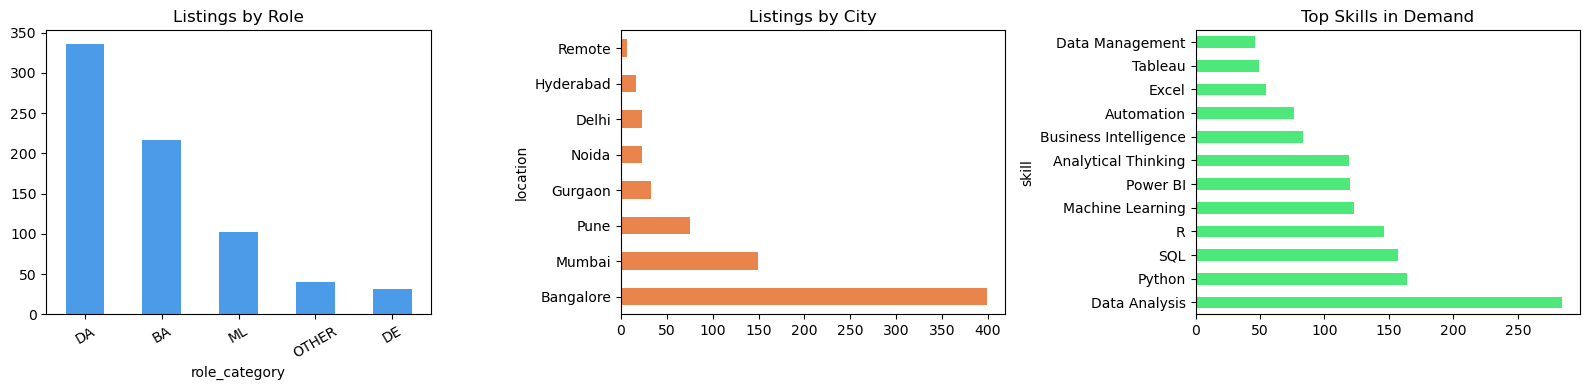


clean_jobs.csv            → 727 rows
clean_skills_exploded.csv → 1690 rows

Preprocessing complete. Move to Cell 12 (Load to MySQL).


In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df["role_category"].value_counts().plot(
    kind="bar", ax=axes[0], color="#4C9BE8")
axes[0].set_title("Listings by Role")
axes[0].tick_params(axis="x", rotation=30)

df["location"].value_counts().head(8).plot(
    kind="barh", ax=axes[1], color="#E8844C")
axes[1].set_title("Listings by City")

df_skills["skill"].value_counts().head(12).plot(
    kind="barh", ax=axes[2], color="#4CE87A")
axes[2].set_title("Top Skills in Demand")

plt.tight_layout()
plt.savefig("data/clean/preprocessing_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Save
df.to_csv(CLEAN_PATH, index=False)
df_skills.to_csv(SKILLS_PATH, index=False)

print(f"\nclean_jobs.csv            → {len(df)} rows")
print(f"clean_skills_exploded.csv → {len(df_skills)} rows")
print("\nPreprocessing complete. Move to Cell 12 (Load to MySQL).")

In [22]:
# R is over-matching because "r " catches too many words
# Fix: only count R if it appears as a standalone skill tag
# (i.e. the entire tag is just "r" or "r programming")

def extract_skills_fixed(raw):
    if pd.isna(raw) or not raw: return []
    
    # Split on comma first — each tag is a separate skill
    tags = [t.strip().lower() for t in str(raw).split(",")]
    found = []
    seen  = set()
    
    SKILL_TAXONOMY_FIXED = {
        "python":            "Python",
        "sql":               "SQL",
        "sql queries":       "SQL",
        "r":                 "R",           # exact tag match only
        "r programming":     "R",
        "java":              "Java",
        "scala":             "Scala",
        "power bi":          "Power BI",
        "powerbi":           "Power BI",
        "tableau":           "Tableau",
        "looker":            "Looker",
        "excel":             "Excel",
        "mysql":             "MySQL",
        "postgresql":        "PostgreSQL",
        "postgres":          "PostgreSQL",
        "mongodb":           "MongoDB",
        "snowflake":         "Snowflake",
        "bigquery":          "BigQuery",
        "redshift":          "Redshift",
        "oracle":            "Oracle",
        "hive":              "Hive",
        "aws":               "AWS",
        "azure":             "Azure",
        "gcp":               "GCP",
        "google cloud":      "GCP",
        "machine learning":  "Machine Learning",
        "deep learning":     "Deep Learning",
        "nlp":               "NLP",
        "tensorflow":        "TensorFlow",
        "pytorch":           "PyTorch",
        "scikit-learn":      "Scikit-learn",
        "scikit":            "Scikit-learn",
        "keras":             "Keras",
        "spark":             "Spark",
        "kafka":             "Kafka",
        "airflow":           "Airflow",
        "dbt":               "dbt",
        "pandas":            "Pandas",
        "numpy":             "NumPy",
        "data analysis":     "Data Analysis",
        "data analytics":    "Data Analysis",
        "data visualization":"Data Visualization",
        "data visualisation":"Data Visualization",
        "statistics":        "Statistics",
        "statistical":       "Statistics",
        "analytical":        "Analytical Thinking",
        "data management":   "Data Management",
        "automation":        "Automation",
        "business intelligence": "Business Intelligence",
        "bi":                "Business Intelligence",
    }
    
    for tag in tags:
        # exact match first
        if tag in SKILL_TAXONOMY_FIXED:
            canonical = SKILL_TAXONOMY_FIXED[tag]
            if canonical not in seen:
                found.append(canonical)
                seen.add(canonical)
            continue
        # partial match for multi-word skills
        for key, canonical in sorted(
            SKILL_TAXONOMY_FIXED.items(), key=lambda x: len(x[0]), reverse=True
        ):
            if key in tag and len(key) > 3:  # min 4 chars to avoid "bi" in "ability"
                if canonical not in seen:
                    found.append(canonical)
                    seen.add(canonical)
                break

    return found

# Reapply
df["skills_list"]  = df["skills_raw"].apply(extract_skills_fixed)
df["skills_count"] = df["skills_list"].apply(len)

# Rebuild exploded skills df
df_skills = df[["title","company","location","scraped_date","role_category"]].copy()
df_skills["skill"] = df["skills_list"]
df_skills = df_skills.explode("skill").dropna(subset=["skill"])
df_skills = df_skills[df_skills["skill"] != ""]

print(f"Skill rows after fix: {len(df_skills)}")
print("\nTop 20 skills (corrected):")
print(df_skills["skill"].value_counts().head(20).to_string())

Skill rows after fix: 1552

Top 20 skills (corrected):
skill
Data Analysis            314
Python                   164
SQL                      144
Machine Learning         123
Power BI                 120
Analytical Thinking      119
Automation                76
Business Intelligence     57
Excel                     55
Tableau                   49
Data Management           46
Data Visualization        45
Azure                     25
Spark                     22
Deep Learning             17
Oracle                    16
TensorFlow                16
GCP                       15
Java                      12
Statistics                12


In [24]:
df.to_csv(CLEAN_PATH, index=False)
df_skills.to_csv(SKILLS_PATH, index=False)

print(f"clean_jobs.csv            → {len(df)} rows")
print(f"clean_skills_exploded.csv → {len(df_skills)} rows")
print("\nPreprocessing complete.")

clean_jobs.csv            → 727 rows
clean_skills_exploded.csv → 1552 rows

Preprocessing complete.


In [25]:
import calendar
from datetime import datetime
from tqdm.notebook import tqdm

conn   = mysql.connector.connect(
    host=MYSQL_HOST, port=MYSQL_PORT,
    user=MYSQL_USER, password=MYSQL_PASSWORD,
    database=MYSQL_DATABASE
)
cursor = conn.cursor()

df        = pd.read_csv(CLEAN_PATH)
df_skills = pd.read_csv(SKILLS_PATH)
print(f"Jobs: {len(df)} | Skills: {len(df_skills)}")

CITY_META = {
    "Bangalore":("Karnataka","South",1), "Mumbai":("Maharashtra","West",1),
    "Delhi":("Delhi","North",1),         "Hyderabad":("Telangana","South",1),
    "Pune":("Maharashtra","West",1),     "Chennai":("Tamil Nadu","South",1),
    "Noida":("UP","North",2),            "Gurgaon":("Haryana","North",2),
    "Indore":("MP","Central",2),
}

def get_or_insert(table, pk, lc, val, extra=None):
    cursor.execute(f"SELECT {pk} FROM {table} WHERE {lc}=%s", (val,))
    row = cursor.fetchone()
    if row: return row[0]
    if extra:
        cols = lc+","+",".join(extra.keys())
        vals = (val,)+tuple(extra.values())
        ph   = ",".join(["%s"]*len(vals))
        cursor.execute(f"INSERT INTO {table} ({cols}) VALUES ({ph})", vals)
    else:
        cursor.execute(f"INSERT INTO {table} ({lc}) VALUES (%s)", (val,))
    conn.commit()
    return cursor.lastrowid

def get_or_insert_location(city):
    city = str(city).strip().title()
    cursor.execute("SELECT location_id FROM dim_location WHERE city=%s", (city,))
    row = cursor.fetchone()
    if row: return row[0]
    s,r,t = CITY_META.get(city,(None,None,None))
    cursor.execute("INSERT INTO dim_location (city,state,region,tier) VALUES (%s,%s,%s,%s)",(city,s,r,t))
    conn.commit()
    return cursor.lastrowid

def get_or_insert_date(d_str):
    d = datetime.strptime(str(d_str),"%Y-%m-%d").date()
    cursor.execute("SELECT date_id FROM dim_date WHERE full_date=%s",(d,))
    row = cursor.fetchone()
    if row: return row[0]
    cursor.execute(
        "INSERT INTO dim_date (full_date,week_number,month,quarter,year,is_month_end) VALUES (%s,%s,%s,%s,%s,%s)",
        (d, d.isocalendar()[1], d.month, (d.month-1)//3+1, d.year,
         d.day==calendar.monthrange(d.year,d.month)[1]))
    conn.commit()
    return cursor.lastrowid

def safe(val, cast=int):
    try: return cast(val) if pd.notna(val) else None
    except: return None

print("Helpers ready.")

Jobs: 727 | Skills: 1552
Helpers ready.


In [26]:
saved = errors = 0

for _, row in tqdm(df.iterrows(), total=len(df), desc="Loading listings"):
    try:
        cid = get_or_insert("dim_company","company_id","company_name",str(row["company"]))
        lid = get_or_insert_location(row["location"])
        did = get_or_insert_date(row["scraped_date"])
        rid = get_or_insert("dim_role","role_id","job_title",str(row["title"]),
                            {"role_category":str(row["role_category"]),
                             "exp_level":    str(row["exp_level"])})
        cursor.execute("""
            INSERT INTO fact_job_listings
                (company_id,location_id,date_id,role_id,
                 salary_min,salary_max,applicant_count,days_open,
                 work_mode,experience_min,experience_max,source,raw_url)
            VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
        """, (cid,lid,did,rid,
              safe(row.get("salary_min")),   safe(row.get("salary_max")),
              safe(row.get("applicant_count")),safe(row.get("days_open")),
              str(row.get("work_mode","onsite")),
              safe(row.get("experience_min")), safe(row.get("experience_max")),
              "naukri", str(row.get("raw_url",""))[:499]))
        conn.commit()
        saved += 1
    except:
        errors += 1

print(f"Listings loaded: {saved} | Skipped: {errors}")

Loading listings:   0%|          | 0/727 [00:00<?, ?it/s]

Listings loaded: 727 | Skipped: 0


In [27]:
SKILL_META = {
    "Python":("language","technical"),   "SQL":("language","technical"),
    "Power BI":("tool","technical"),     "Tableau":("tool","technical"),
    "Excel":("tool","technical"),        "MySQL":("platform","technical"),
    "Snowflake":("platform","technical"),"AWS":("platform","technical"),
    "Azure":("platform","technical"),    "GCP":("platform","technical"),
    "Machine Learning":("language","technical"),
    "Deep Learning":("language","technical"),
    "NLP":("language","technical"),      "TensorFlow":("tool","technical"),
    "PyTorch":("tool","technical"),      "Scikit-learn":("tool","technical"),
    "Spark":("tool","technical"),        "Pandas":("tool","technical"),
    "NumPy":("tool","technical"),        "Airflow":("tool","technical"),
}

cursor.execute("""
    SELECT fjl.listing_id, r.job_title, c.company_name, d.full_date
    FROM fact_job_listings fjl
    JOIN dim_role    r ON fjl.role_id    = r.role_id
    JOIN dim_company c ON fjl.company_id = c.company_id
    JOIN dim_date    d ON fjl.date_id    = d.date_id
""")
listing_map = {(r[1],r[2],str(r[3])):r[0] for r in cursor.fetchall()}

sk_saved = sk_errors = 0

for _, row in tqdm(df_skills.iterrows(), total=len(df_skills), desc="Loading skills"):
    try:
        key = (str(row["title"]).strip().title(),
               str(row["company"]).strip().title(),
               str(row["scraped_date"]))
        lid = listing_map.get(key)
        if not lid: continue

        sn = str(row["skill"]).strip()
        cat, stype = SKILL_META.get(sn, ("tool","technical"))

        cursor.execute("SELECT skill_id FROM dim_skill WHERE skill_name=%s",(sn,))
        sr = cursor.fetchone()
        if sr: sid = sr[0]
        else:
            cursor.execute(
                "INSERT INTO dim_skill (skill_name,skill_category,skill_type) VALUES (%s,%s,%s)",
                (sn,cat,stype))
            conn.commit()
            sid = cursor.lastrowid

        wk = datetime.strptime(str(row["scraped_date"]),"%Y-%m-%d").date().isocalendar()[1]
        cursor.execute(
            "INSERT IGNORE INTO fact_skill_listings (listing_id,skill_id,scraped_week) VALUES (%s,%s,%s)",
            (lid,sid,wk))
        conn.commit()
        sk_saved += 1
    except:
        sk_errors += 1

conn.close()
print(f"Skills loaded: {sk_saved} | Skipped: {sk_errors}")

Loading skills:   0%|          | 0/1552 [00:00<?, ?it/s]

Skills loaded: 1552 | Skipped: 0


In [30]:
conn   = mysql.connector.connect(
    host=MYSQL_HOST, port=MYSQL_PORT,
    user=MYSQL_USER, password=MYSQL_PASSWORD,
    database=MYSQL_DATABASE
)
cursor = conn.cursor()

VIEWS = {
"vw_skill_velocity": """
CREATE OR REPLACE VIEW vw_skill_velocity AS
WITH weekly_counts AS (
    SELECT s.skill_name, s.skill_category, d.week_number, d.year,
           COUNT(*) AS weekly_mentions
    FROM fact_skill_listings fsl
    JOIN dim_skill         s   ON fsl.skill_id   = s.skill_id
    JOIN fact_job_listings fjl ON fsl.listing_id = fjl.listing_id
    JOIN dim_date          d   ON fjl.date_id    = d.date_id
    GROUP BY s.skill_name, s.skill_category, d.week_number, d.year
),
with_rolling AS (
    SELECT *, ROUND(AVG(weekly_mentions) OVER (
        PARTITION BY skill_name ORDER BY year, week_number
        ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
    ),1) AS rolling_4wk_avg FROM weekly_counts
)
SELECT skill_name, skill_category, week_number, year,
       weekly_mentions, rolling_4wk_avg,
       ROUND(weekly_mentions/NULLIF(rolling_4wk_avg,0),2) AS velocity,
       CASE
           WHEN weekly_mentions/NULLIF(rolling_4wk_avg,0)>=1.2 THEN 'RISING'
           WHEN weekly_mentions/NULLIF(rolling_4wk_avg,0)<=0.8 THEN 'DECLINING'
           ELSE 'STABLE'
       END AS trend_label
FROM with_rolling WHERE rolling_4wk_avg IS NOT NULL""",

"vw_hiring_difficulty": """
CREATE OR REPLACE VIEW vw_hiring_difficulty AS
SELECT r.role_category, l.city, l.tier,
       COUNT(DISTINCT fjl.listing_id)            AS open_roles,
       COALESCE(SUM(fjl.applicant_count),0)       AS total_applicants,
       ROUND(COUNT(DISTINCT fjl.listing_id)*100.0
             /NULLIF(SUM(fjl.applicant_count),0),4) AS difficulty_score,
       RANK() OVER (PARTITION BY l.city
           ORDER BY COUNT(DISTINCT fjl.listing_id)*1.0
                    /NULLIF(SUM(fjl.applicant_count),0) DESC
       ) AS city_difficulty_rank
FROM fact_job_listings fjl
JOIN dim_role     r ON fjl.role_id     = r.role_id
JOIN dim_location l ON fjl.location_id = l.location_id
GROUP BY r.role_category, l.city, l.tier""",

"vw_salary_intelligence": """
CREATE OR REPLACE VIEW vw_salary_intelligence AS
WITH monthly AS (
    SELECT r.role_category, r.exp_level, l.city, d.month, d.year,
           ROUND(AVG((fjl.salary_min+fjl.salary_max)/2.0),1) AS avg_mid_salary,
           MIN(fjl.salary_min) AS min_salary,
           MAX(fjl.salary_max) AS max_salary,
           COUNT(*) AS listing_count
    FROM fact_job_listings fjl
    JOIN dim_role     r ON fjl.role_id     = r.role_id
    JOIN dim_location l ON fjl.location_id = l.location_id
    JOIN dim_date     d ON fjl.date_id     = d.date_id
    WHERE fjl.salary_min IS NOT NULL
    GROUP BY r.role_category, r.exp_level, l.city, d.month, d.year
)
SELECT *, LAG(avg_mid_salary) OVER (
    PARTITION BY role_category,exp_level,city ORDER BY year,month
) AS prev_month_salary,
ROUND((avg_mid_salary - LAG(avg_mid_salary) OVER (
    PARTITION BY role_category,exp_level,city ORDER BY year,month
))*100.0/NULLIF(LAG(avg_mid_salary) OVER (
    PARTITION BY role_category,exp_level,city ORDER BY year,month
),0),2) AS mom_pct_change
FROM monthly""",

"vw_skill_cooccurrence": """
CREATE OR REPLACE VIEW vw_skill_cooccurrence AS
SELECT s1.skill_name AS skill_a, s2.skill_name AS skill_b,
       s1.skill_category AS category_a,
       COUNT(*) AS co_occurrences,
       ROUND(COUNT(*)*100.0/(
           SELECT COUNT(DISTINCT listing_id) FROM fact_skill_listings
       ),2) AS pct_of_all_jobs
FROM fact_skill_listings fsl1
JOIN fact_skill_listings fsl2
    ON fsl1.listing_id=fsl2.listing_id AND fsl1.skill_id<fsl2.skill_id
JOIN dim_skill s1 ON fsl1.skill_id=s1.skill_id
JOIN dim_skill s2 ON fsl2.skill_id=s2.skill_id
GROUP BY s1.skill_name, s2.skill_name, s1.skill_category
HAVING COUNT(*) > 10
ORDER BY co_occurrences DESC""",

"vw_fresher_hotspots": """
CREATE OR REPLACE VIEW vw_fresher_hotspots AS
SELECT l.city, l.tier, l.region, r.role_category,
       COUNT(*) AS total_openings,
       ROUND(AVG(fjl.salary_max),1)        AS avg_max_salary_lpa,
       ROUND(AVG(fjl.applicant_count),0)   AS avg_competition,
       DENSE_RANK() OVER (ORDER BY COUNT(*) DESC) AS opportunity_rank
FROM fact_job_listings fjl
JOIN dim_role     r ON fjl.role_id     = r.role_id
JOIN dim_location l ON fjl.location_id = l.location_id
WHERE r.exp_level = 'fresher'
GROUP BY l.city, l.tier, l.region, r.role_category
HAVING COUNT(*) >= 5""",

"vw_top_skills_by_role": """
CREATE OR REPLACE VIEW vw_top_skills_by_role AS
WITH ranked AS (
    SELECT r.role_category, s.skill_name, s.skill_category,
           COUNT(DISTINCT fjl.listing_id) AS listings_requiring,
           ROUND(COUNT(DISTINCT fjl.listing_id)*100.0/NULLIF((
               SELECT COUNT(DISTINCT listing_id) FROM fact_job_listings fjl2
               JOIN dim_role r2 ON fjl2.role_id=r2.role_id
               WHERE r2.role_category=r.role_category
           ),0),1) AS pct_of_role_listings,
           ROW_NUMBER() OVER (
               PARTITION BY r.role_category
               ORDER BY COUNT(DISTINCT fjl.listing_id) DESC
           ) AS skill_rank
    FROM fact_skill_listings fsl
    JOIN fact_job_listings fjl ON fsl.listing_id = fjl.listing_id
    JOIN dim_skill         s   ON fsl.skill_id   = s.skill_id
    JOIN dim_role          r   ON fjl.role_id    = r.role_id
    GROUP BY r.role_category, s.skill_name, s.skill_category
)
SELECT * FROM ranked WHERE skill_rank <= 15"""
}

for name, sql in VIEWS.items():
    try:
        cursor.execute(sql)
        conn.commit()
        print(f"   {name}")
    except Exception as e:
        print(f"    {name}: {e}")

   vw_skill_velocity
   vw_hiring_difficulty
   vw_salary_intelligence
   vw_skill_cooccurrence
   vw_fresher_hotspots
   vw_top_skills_by_role
